In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/sample_submission.csv
/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv
/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv


## Import libraries

In [2]:
#visulaization libraries
import seaborn as sns
import matplotlib.pyplot as plt

#ML libraries
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
from sklearn.model_selection import KFold
import xgboost as xgb

## Data directory

In [3]:
train_df = pd.read_csv(
    "/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/train.csv"
)

test_df = pd.read_csv(
    "/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/test.csv"
)


## Data Exploration

In [4]:
print(train_df.columns)
train_df.head(15)


Index(['id', 'product_code', 'product_weight_kg', 'fat_content',
       'shelf_visibility', 'product_category', 'product_price', 'store_code',
       'store_age_years', 'store_size', 'store_location_tier', 'store_format',
       'total_sales'],
      dtype='object')


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36
5,row_00005,PRD-E6VA05,9.222,Low Fat,0.0405,soft drinks,31.69,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,842.75
6,row_00006,PRD-MHLD93,NaN,Low Fat,0.1239,Canned,212.23,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,4512.70
7,row_00007,PRD-EF6Y39,10.210,Regular,0.0133,Snack Foods,142.70,STORE-HL7,23,Medium,Tier_3,Superstore,2373.55
8,row_00008,PRD-IAZMTU,14.054,Low Fat,0.0233,baking goods,102.71,STORE-HL7,23,Medium,Tier_3,Superstore,2037.05
9,row_00010,PRD-DH2TA3,8.755,Low Fat,0.0258,household,104.60,STORE-JOR,34,NaN,Tier_3,Corner Shop,213.93


In [5]:
train_df.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [6]:
missing = train_df.isnull().sum()

missing_pct = (missing / len(train_df)) * 100
print(f'Missing values in percentage\n{missing_pct}')

Missing values in percentage
id                      0.000000
product_code            0.000000
product_weight_kg      17.967146
fat_content             0.000000
shelf_visibility        0.000000
product_category        0.000000
product_price           0.000000
store_code              0.000000
store_age_years         0.000000
store_size             28.146084
store_location_tier     0.000000
store_format            0.000000
total_sales             0.000000
dtype: float64


In [7]:
## can a product have a shelf visibility of zero or is that an artifact?
zero_count = (train_df['shelf_visibility'] == 0).sum()
print(f"Number of zero visibility rows: {zero_count}")

Number of zero visibility rows: 422


## Fill missing values


In [8]:
#fill missing values in the product weight kg. I used median here because it's more robust to skew and outliers.
median_weight = train_df["product_weight_kg"].median()

train_df["product_weight_kg"] = train_df["product_weight_kg"].fillna(median_weight)
test_df["product_weight_kg"] = test_df["product_weight_kg"].fillna(median_weight)

#fill missng values in store size, i didn't want to make assumptions
train_df["store_size"] = train_df["store_size"].fillna("Missing")
test_df["store_size"] = test_df["store_size"].fillna("Missing")


print("train_df nulls:\n", train_df[["product_weight_kg", "store_size"]].isnull().sum())
print("test_df nulls:\n", test_df[["product_weight_kg", "store_size"]].isnull().sum())

train_df nulls:
 product_weight_kg    0
store_size           0
dtype: int64
test_df nulls:
 product_weight_kg    0
store_size           0
dtype: int64


In [9]:

# store_size_lookup = train_df.groupby("store_code")["store_size"].agg(
#     lambda x: x.mode()[0] if x.notna().any() else None
# )

# train_df["store_size"] = train_df["store_size"].fillna(train_df["store_code"].map(store_size_lookup))
# test_df["store_size"] = test_df["store_size"].fillna(test_df["store_code"].map(store_size_lookup))


# format_size_lookup = train_df.groupby("store_format")["store_size"].agg(
#     lambda x: x.mode()[0] if x.notna().any() else None
# )

# train_df["store_size"] = train_df["store_size"].fillna(train_df["store_format"].map(format_size_lookup))
# test_df["store_size"] = test_df["store_size"].fillna(test_df["store_format"].map(format_size_lookup))



## Data cleaning


In [10]:
def clean_category(series):
    cleaned = series.str.strip().str.lower()
    cleaned = cleaned.str.split().apply(
        lambda words: " ".join(w.capitalize() if w != "and" else w for w in words)
    )
    return cleaned

train_df["product_category"] = clean_category(train_df["product_category"])
test_df["product_category"] = clean_category(test_df["product_category"])

print(sorted(train_df["product_category"].unique()))

['Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy', 'Frozen Foods', 'Fruits and Vegetables', 'Hard Drinks', 'Health and Hygiene', 'Household', 'Meat', 'Others', 'Seafood', 'Snack Foods', 'Soft Drinks', 'Starchy Foods']


## VISUALIZATION

/tmp/ipykernel_16/191543808.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


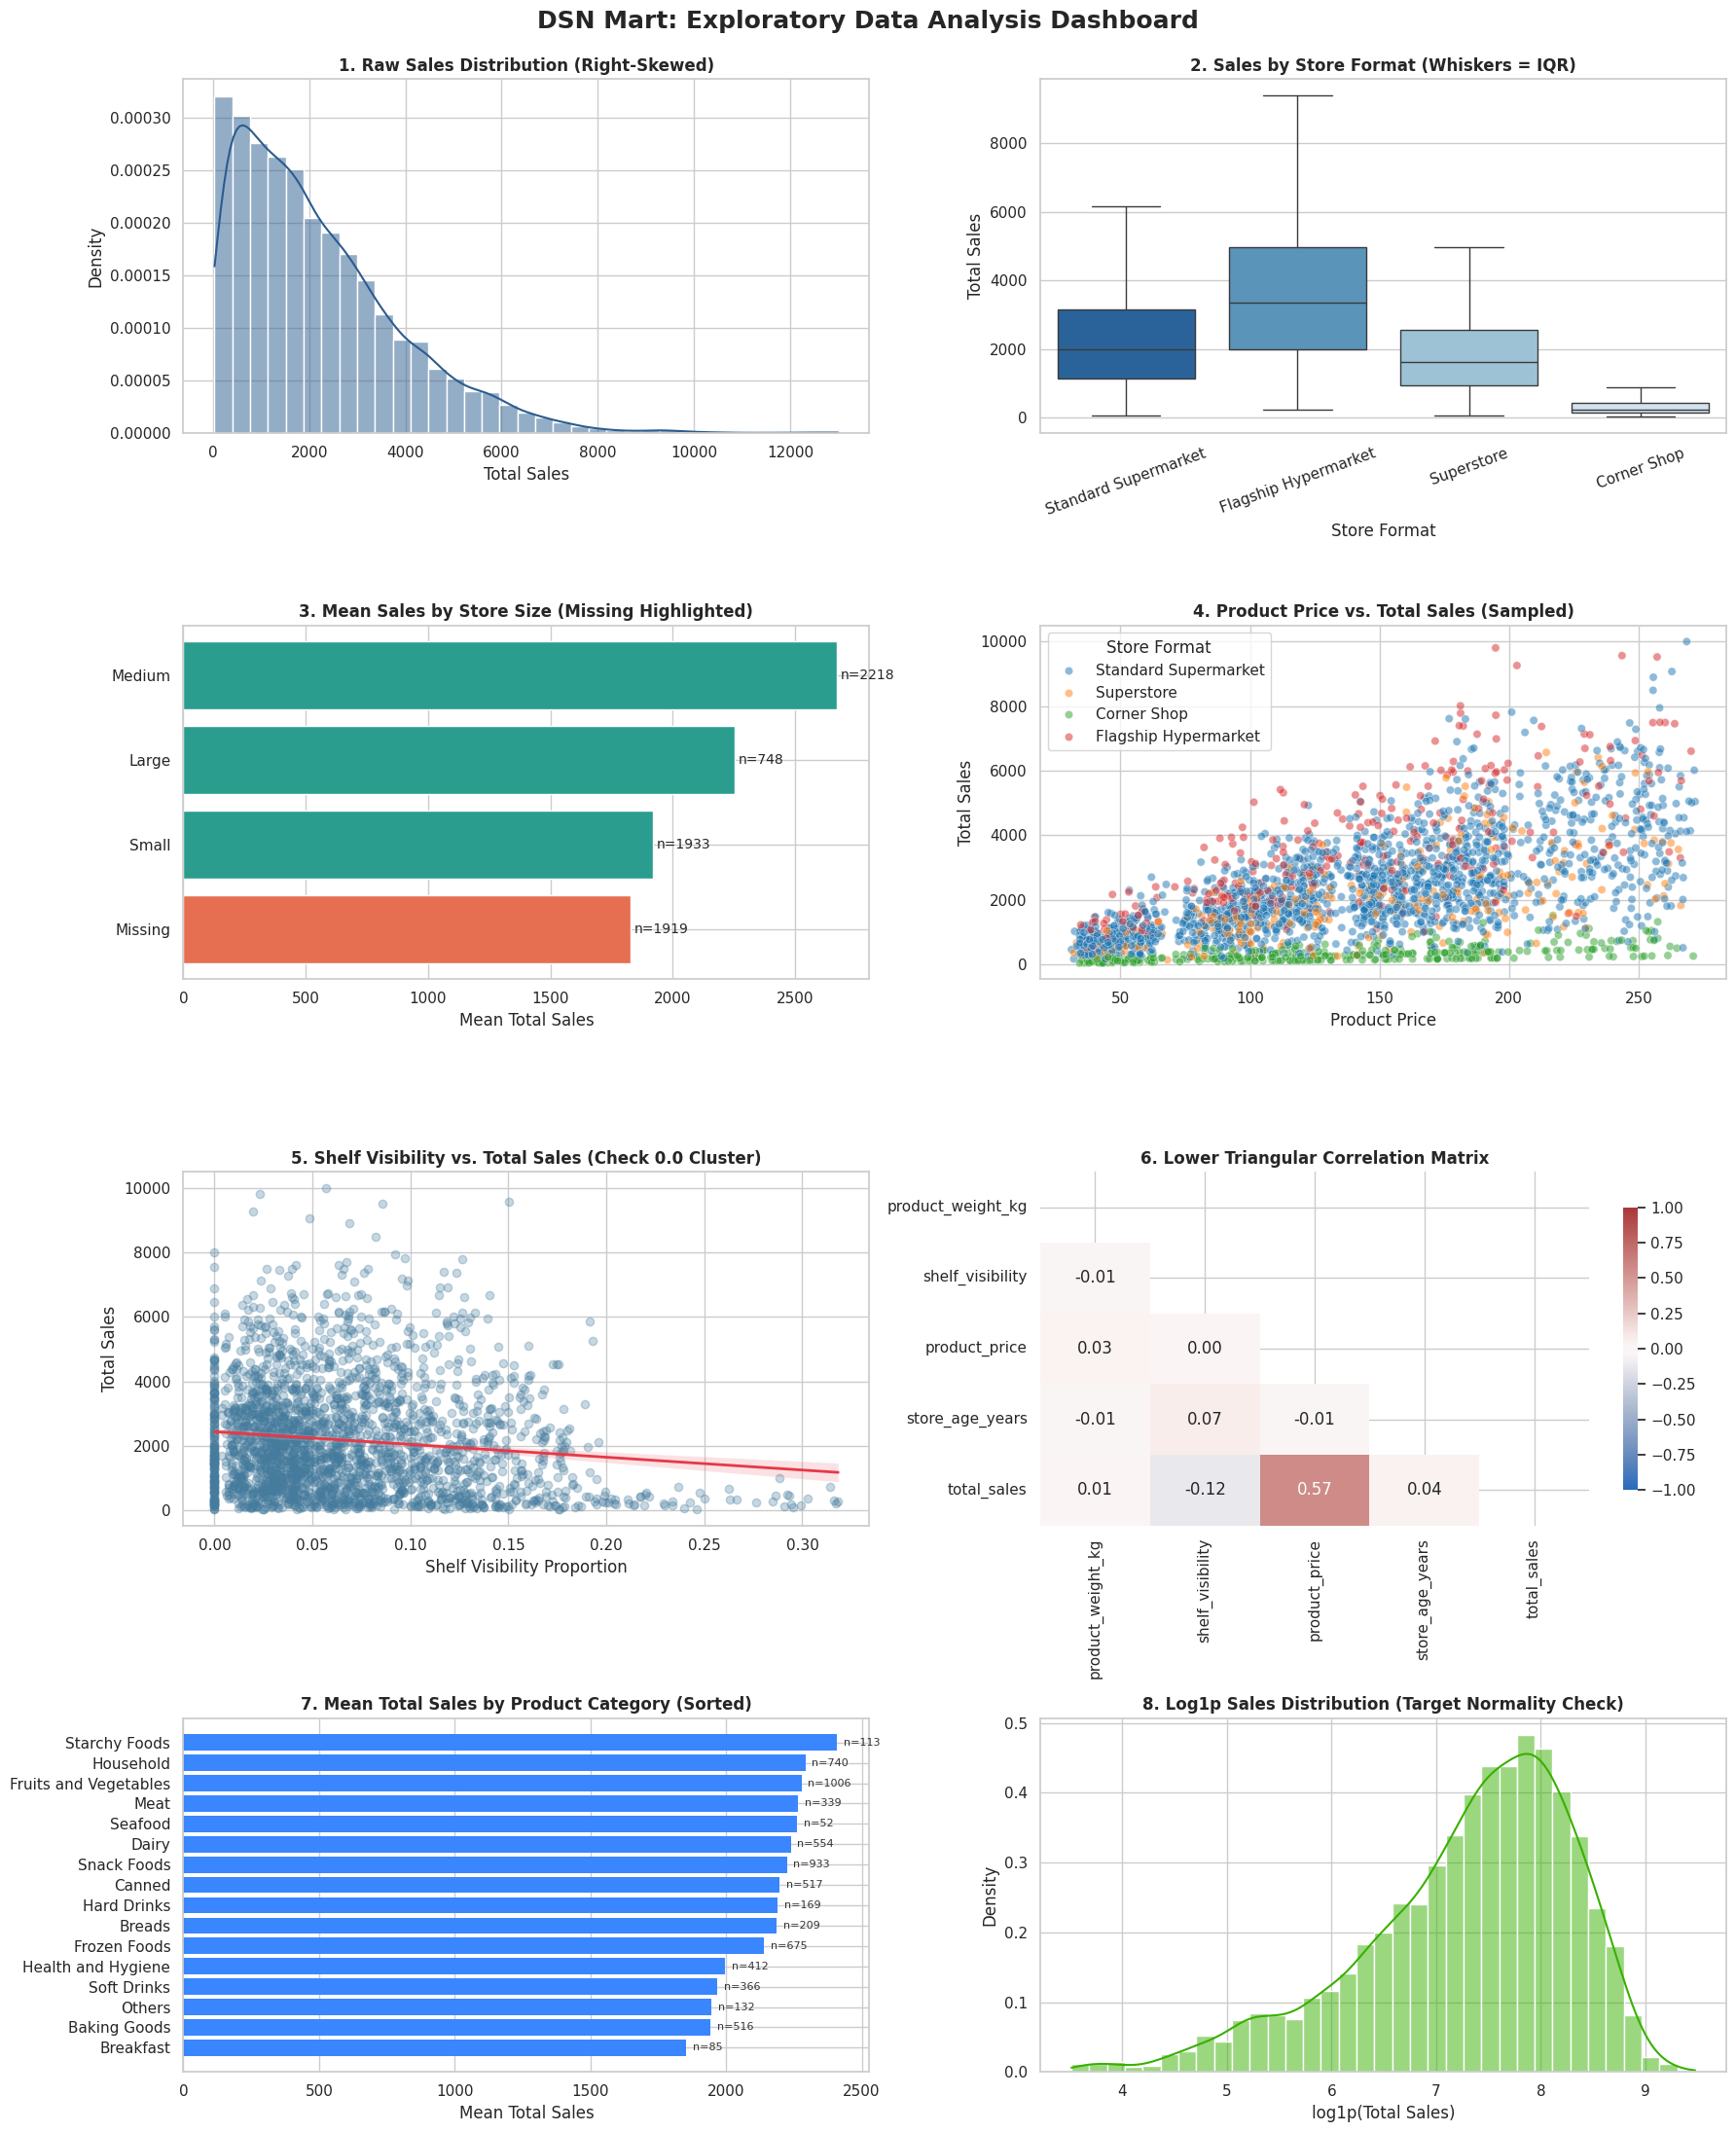

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def run_retail_eda_dashboard(df, target_col="total_sales"):
    """Generates an 8-panel visual diagnostic dashboard for the DSN retail dataset."""
    sns.set_theme(style="whitegrid", palette="muted")
    fig, axes = plt.subplots(4, 2, figsize=(18, 22))
    fig.suptitle(
        "DSN Mart: Exploratory Data Analysis Dashboard",
        fontsize=18,
        fontweight="bold",
        y=0.995,
    )

    # 1. Target Distribution & Skewness
    ax1 = axes[0, 0]
    sns.histplot(
        df[target_col],
        kde=True,
        ax=ax1,
        color="#2b5c8f",
        bins=35,
        stat="density",
    )
    ax1.set_title(
        "1. Raw Sales Distribution (Right-Skewed)",
        fontweight="bold",
        fontsize=12,
    )
    ax1.set_xlabel("Total Sales")

    # 2. Store Format vs Total Sales
    ax2 = axes[0, 1]
    sns.boxplot(
        data=df,
        x="store_format",
        y=target_col,
        ax=ax2,
        palette="Blues_r",
        showfliers=False,
    )
    ax2.set_title(
        "2. Sales by Store Format (Whiskers = IQR)",
        fontweight="bold",
        fontsize=12,
    )
    ax2.set_xlabel("Store Format")
    ax2.set_ylabel("Total Sales")
    ax2.tick_params(axis="x", rotation=20)

    # 3. Store Size (Including 'Missing') vs Mean Sales
    ax3 = axes[1, 0]
    size_series = df["store_size"].fillna("Missing")
    size_sales = (
        df.groupby(size_series)[target_col]
        .agg(["mean", "count"])
        .sort_values(by="mean", ascending=True)
    )
    bars = ax3.barh(
        size_sales.index,
        size_sales["mean"],
        color=[
            "#e76f51" if x == "Missing" else "#2a9d8f" for x in size_sales.index
        ],
    )
    ax3.set_title(
        "3. Mean Sales by Store Size (Missing Highlighted)",
        fontweight="bold",
        fontsize=12,
    )
    ax3.set_xlabel("Mean Total Sales")
    for bar, count in zip(bars, size_sales["count"]):
        ax3.text(
            bar.get_width() + 15,
            bar.get_y() + bar.get_height() / 2,
            f"n={count}",
            va="center",
            fontsize=10,
        )

    # 4. Product Price vs Total Sales
    ax4 = axes[1, 1]
    sample_df = df.sample(min(2500, len(df)), random_state=42)
    sns.scatterplot(
        data=sample_df,
        x="product_price",
        y=target_col,
        hue="store_format",
        alpha=0.5,
        ax=ax4,
        palette="tab10",
    )
    ax4.set_title(
        "4. Product Price vs. Total Sales (Sampled)",
        fontweight="bold",
        fontsize=12,
    )
    ax4.set_xlabel("Product Price")
    ax4.set_ylabel("Total Sales")
    ax4.legend(title="Store Format", loc="upper left", framealpha=0.8)

    # 5. Shelf Visibility vs Sales (Zero-audit spike check)
    ax5 = axes[2, 0]
    sns.regplot(
        data=sample_df,
        x="shelf_visibility",
        y=target_col,
        ax=ax5,
        scatter_kws={"alpha": 0.3, "color": "#457b9d"},
        line_kws={"color": "#e63946", "linewidth": 2},
    )
    ax5.set_title(
        "5. Shelf Visibility vs. Total Sales (Check 0.0 Cluster)",
        fontweight="bold",
        fontsize=12,
    )
    ax5.set_xlabel("Shelf Visibility Proportion")
    ax5.set_ylabel("Total Sales")

    # 6. Numeric Feature Correlation Heatmap
    ax6 = axes[2, 1]
    num_cols = df.select_dtypes(include=[np.number]).columns
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        vmin=-1,
        vmax=1,
        mask=mask,
        ax=ax6,
        cbar_kws={"shrink": 0.8},
    )
    ax6.set_title(
        "6. Lower Triangular Correlation Matrix",
        fontweight="bold",
        fontsize=12,
    )

    # 7. Category-level Average Sales (Sorted Horizontal Bar)
    ax7 = axes[3, 0]
    cat_summary = (
        df.groupby("product_category")[target_col]
        .agg(["mean", "count"])
        .sort_values(by="mean", ascending=True)
    )
    cat_bars = ax7.barh(
        cat_summary.index, cat_summary["mean"], color="#3a86ff", edgecolor="none"
    )
    ax7.set_title(
        "7. Mean Total Sales by Product Category (Sorted)",
        fontweight="bold",
        fontsize=12,
    )
    ax7.set_xlabel("Mean Total Sales")
    max_w = cat_summary["mean"].max()
    for bar, count in zip(cat_bars, cat_summary["count"]):
        ax7.text(
            bar.get_width() + (max_w * 0.01),
            bar.get_y() + bar.get_height() / 2,
            f"n={count}",
            va="center",
            fontsize=8,
            color="#333333",
        )

    # 8. Log Target Distribution Check
    ax8 = axes[3, 1]
    sns.histplot(
        np.log1p(df[target_col]),
        kde=True,
        ax=ax8,
        color="#38b000",
        bins=35,
        stat="density",
    )
    ax8.set_title(
        "8. Log1p Sales Distribution (Target Normality Check)",
        fontweight="bold",
        fontsize=12,
    )
    ax8.set_xlabel("log1p(Total Sales)")

    plt.tight_layout()
    plt.show()


# Run the dashboard:
run_retail_eda_dashboard(train_df)

## BASELINE MODEL BEFORE FEATURE ENGINEERING

In [12]:
X = train_df.drop(columns=["total_sales", "id"]).copy()
y = train_df["total_sales"].copy()


cat_cols = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()


for col in cat_cols:
    X[col] = X[col].fillna("Missing").astype(str)


print("Categorical columns:")
print(cat_cols)

print("\nFeature shape:", X.shape)


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\nTrain:", X_train.shape)
print("Validation:", X_valid.shape)


first_baseline_model = CatBoostRegressor(
    iterations=120,
    learning_rate=0.06,
    depth=7,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

first_baseline_model.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100
)


first_prediction = first_baseline_model.predict(X_valid)

rmse = np.sqrt(
    mean_squared_error(y_valid, first_prediction)
)

print("\n==============================")
print(f"BASELINE RMSE: {rmse:.4f}")
print(f"BEST ITERATION: {first_baseline_model.get_best_iteration()}")
print("==============================")

Categorical columns:
['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']

Feature shape: (6818, 11)

Train: (5454, 11)
Validation: (1364, 11)
0:	learn: 1639.0580567	test: 1663.1571818	best: 1663.1571818 (0)	total: 60.8ms	remaining: 7.24s
100:	learn: 1043.3004650	test: 1065.2126458	best: 1065.2126458 (100)	total: 293ms	remaining: 55.2ms
119:	learn: 1034.2295281	test: 1066.3853533	best: 1065.0236433 (103)	total: 336ms	remaining: 0us

bestTest = 1065.023643
bestIteration = 103

Shrink model to first 104 iterations.

BASELINE RMSE: 1065.0236
BEST ITERATION: 103


In [13]:
features = test_df.drop(columns=["id"])
features.head()

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,PRD-2WLNC8,8.628,Low Fat,0.0167,Household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,PRD-ET6ZI7,12.647,Low Fat,0.1262,Fruits and Vegetables,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,PRD-6RX35U,14.034,Regular,0.0761,Frozen Foods,200.71,STORE-DKU,30,Missing,Tier_2,Standard Supermarket
4,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


In [14]:
base_prediction= first_baseline_model.predict(features)
base_prediction

array([2894.22371689, 4168.09858317, 3059.35406719, ..., 2847.57412153,
       4268.48629553, 1708.28725329])

In [15]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "total_sales": base_prediction
})
submission.to_csv("base2_submission.csv", index=False)
print(submission.head())

#this was the final submission i used

          id  total_sales
0  row_00009  2894.223717
1  row_00015  4168.098583
2  row_00019  3059.354067
3  row_00020  3280.621841
4  row_00023  2508.925608


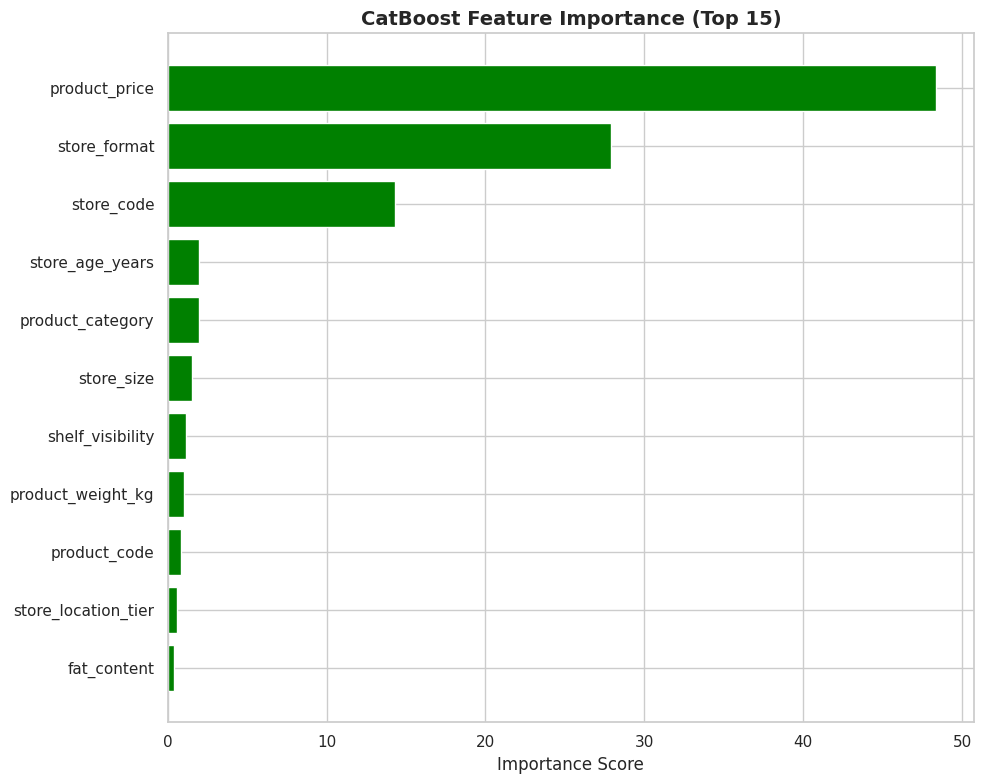

In [16]:
feature_names = first_baseline_model.feature_names_


importances = np.array(first_baseline_model.get_feature_importance()).ravel()

importance_df = pd.DataFrame(
    {"feature": feature_names, "importance": importances}
).sort_values("importance", ascending=True)

#Plot top 15 features
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df["feature"].tail(15),
    importance_df["importance"].tail(15),
    color="green",
)
plt.title(
    "CatBoost Feature Importance (Top 15)", fontsize=14, fontweight="bold"
)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

## Feature engineering
1. For my catboost model, i noticed that feature engineering didn't reduce the RMSE

In [18]:
def engineer_features(train_df, test_df):
    """Clean and engineer features for DSN Mart sales prediction.

    Ensures zero data leakage from test to train.
    """
    train = train_df.copy()
    test = test_df.copy()

    # Track train vs test
    train["is_train"] = 1
    test["is_train"] = 0
    test["total_sales"] = np.nan

    combined = pd.concat([train, test], ignore_index=True)

   
    combined["product_category"] = (
        combined["product_category"].astype(str).str.strip().str.title()
    )

    # Broad product type from code prefix (FD = Food, DR = Drink, NC = Non-Consumable)
    combined["product_type_broad"] = (
        combined["product_code"].astype(str).str[:2]
    )

    # Non-consumable items logically have no fat content
    combined.loc[
        combined["product_type_broad"] == "NC", "fat_content"
    ] = "Non-Edible"

   
    train_mask = combined["is_train"] == 1

    # Product weight: product-level mean -> category median fallback
    item_weight_map = (
        combined.loc[train_mask]
        .groupby("product_code")["product_weight_kg"]
        .mean()
        .to_dict()
    )
    cat_weight_map = (
        combined.loc[train_mask]
        .groupby("product_category")["product_weight_kg"]
        .median()
        .to_dict()
    )

    combined["product_weight_kg"] = combined["product_weight_kg"].fillna(
        combined["product_code"].map(item_weight_map)
    )
    combined["product_weight_kg"] = combined["product_weight_kg"].fillna(
        combined["product_category"].map(cat_weight_map)
    )
    combined["product_weight_kg"] = combined["product_weight_kg"].fillna(
        combined["product_weight_kg"].median()
    )

    # Store size: fill with explicit 'Missing' category (retains structural signal)
    combined["store_size"] = combined["store_size"].fillna("Missing")

    # Shelf visibility: preserve 0.0 flag, impute using product/category positive averages
    combined["visibility_was_zero"] = (
        combined["shelf_visibility"] == 0
    ).astype(int)
    pos_vis = combined.loc[
        train_mask & (combined["shelf_visibility"] > 0)
    ]

    item_vis_map = (
        pos_vis.groupby("product_code")["shelf_visibility"].mean().to_dict()
    )
    cat_vis_map = (
        pos_vis.groupby("product_category")["shelf_visibility"].median().to_dict()
    )

    zero_mask = combined["shelf_visibility"] == 0
    combined.loc[zero_mask, "shelf_visibility"] = combined.loc[
        zero_mask, "product_code"
    ].map(item_vis_map)
    combined["shelf_visibility"] = combined["shelf_visibility"].fillna(
        combined["product_category"].map(cat_vis_map)
    )
    combined["shelf_visibility"] = combined["shelf_visibility"].fillna(
        pos_vis["shelf_visibility"].median()
    )

    # =========================================================================
    # 3. HIGH-LEVERAGE RATIOS & DYNAMICS
    # =========================================================================
    # Relative Shelf Visibility (store, product, category baselines)
    combined["vis_ratio_store"] = combined["shelf_visibility"] / (
        combined.groupby("store_code")["shelf_visibility"].transform("mean")
        + 1e-6
    )
    combined["vis_ratio_product"] = combined["shelf_visibility"] / (
        combined.groupby("product_code")["shelf_visibility"].transform("mean")
        + 1e-6
    )
    combined["vis_ratio_cat"] = combined["shelf_visibility"] / (
        combined.groupby("product_category")["shelf_visibility"].transform(
            "mean"
        )
        + 1e-6
    )

    # Shelf prominence value
    combined["visibility_x_price"] = (
        combined["shelf_visibility"] * combined["product_price"]
    )
    combined["log_shelf_visibility"] = np.log1p(combined["shelf_visibility"])

    # Price Economics
    combined["price_per_kg"] = combined["product_price"] / combined[
        "product_weight_kg"
    ].clip(lower=0.1)

    combined["price_vs_cat_mean"] = combined["product_price"] / (
        combined.groupby("product_category")["product_price"].transform("mean")
        + 1e-6
    )
    combined["price_vs_store_mean"] = combined["product_price"] / (
        combined.groupby("store_code")["product_price"].transform("mean")
        + 1e-6
    )

    # Price tiers (natural price clustering bins)
    combined["price_tier"] = pd.qcut(
        combined["product_price"],
        q=4,
        labels=["Budget", "Standard", "Premium", "Luxury"],
    ).astype(str)

    # =========================================================================
    # 4. STORE & INTERACTION FEATURES
    # =========================================================================
    # Structural pairings
    combined["store_profile"] = (
        combined["store_format"].astype(str)
        + "_"
        + combined["store_location_tier"].astype(str)
    )
    combined["size_format"] = (
        combined["store_size"].astype(str)
        + "_"
        + combined["store_format"].astype(str)
    )
    combined["cat_format"] = (
        combined["product_category"].astype(str)
        + "_"
        + combined["store_format"].astype(str)
    )

    # Store age buckets
    combined["store_age_bucket"] = pd.cut(
        combined["store_age_years"],
        bins=[-1, 5, 10, 15, 20, 100],
        labels=["0-5", "6-10", "11-15", "16-20", "20+"],
    ).astype(str)

    # =========================================================================
    # 5. FREQUENCY & DENSITY ENCODINGS
    # =========================================================================
    for col in [
        "product_code",
        "store_code",
        "product_category",
        "store_profile",
    ]:
        freq_map = (
            combined.loc[train_mask, col]
            .value_counts(normalize=True)
            .to_dict()
        )
        combined[f"{col}_freq"] = (
            combined[col].map(freq_map).fillna(0.0).astype(float)
        )

    # Split back to train and test
    clean_train = (
        combined[combined["is_train"] == 1]
        .drop(columns=["is_train"])
        .reset_index(drop=True)
    )
    clean_test = (
        combined[combined["is_train"] == 0]
        .drop(columns=["is_train", "total_sales"])
        .reset_index(drop=True)
    )

    return clean_train, clean_test


# Execute feature engineering
clean_train_df, clean_test_df = engineer_features(train_df, test_df)

print(f"Clean train shape: {clean_train_df.shape}")
print(f"Clean test shape:  {clean_test_df.shape}")
print(
    f"Remaining NaNs in train: {clean_train_df.drop(columns=['total_sales']).isna().sum().sum()}"
)
print(f"Remaining NaNs in test:  {clean_test_df.isna().sum().sum()}")

Clean train shape: (6818, 32)
Clean test shape:  (1705, 31)
Remaining NaNs in train: 0
Remaining NaNs in test:  0


In [19]:
X = clean_train_df.drop(columns=["total_sales", "id"]).copy()
y = clean_train_df["total_sales"].copy()


cat_cols = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()


for col in cat_cols:
    X[col] = X[col].fillna("Missing").astype(str)


print("Categorical columns:")
print(cat_cols)

print("\nFeature shape:", X.shape)


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\nTrain:", X_train.shape)
print("Validation:", X_valid.shape)


second_baseline_model = CatBoostRegressor(
    iterations=120,
    learning_rate=0.06,
    depth=7,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

second_baseline_model.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100
)


second_prediction = second_baseline_model.predict(X_valid)

rmse = np.sqrt(
    mean_squared_error(y_valid, second_prediction)
)

print("\n==============================")
print(f"BASELINE RMSE: {rmse:.4f}")
print(f"BEST ITERATION: {second_baseline_model.get_best_iteration()}")
print("==============================")

Categorical columns:
['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format', 'product_type_broad', 'price_tier', 'store_profile', 'size_format', 'cat_format', 'store_age_bucket']

Feature shape: (6818, 30)

Train: (5454, 30)
Validation: (1364, 30)
0:	learn: 1638.7069704	test: 1662.1992008	best: 1662.1992008 (0)	total: 6.5ms	remaining: 773ms
100:	learn: 1028.6598127	test: 1066.5211227	best: 1066.1796167 (90)	total: 485ms	remaining: 91.2ms
119:	learn: 1016.4136432	test: 1065.3303680	best: 1065.3303680 (119)	total: 576ms	remaining: 0us

bestTest = 1065.330368
bestIteration = 119


BASELINE RMSE: 1065.3304
BEST ITERATION: 119


## LGM

In [20]:
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# ============================================================
# 1. Prepare features
# ============================================================

drop_cols = ["id", "total_sales"]
feature_cols = [c for c in train_df.columns if c not in drop_cols]

cat_cols = train_df[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()

for col in cat_cols:
    train_df[col] = train_df[col].astype("category")
    test_df[col] = test_df[col].astype("category")

X = train_df[feature_cols]
y = train_df["total_sales"]
X_test = test_df[feature_cols]

# ============================================================
# 2. K-Fold cross-validation
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_df))
test_preds = np.zeros(len(test_df))

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.03,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbosity": -1,
    "seed": 42,
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
    val_set = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols, reference=train_set)

    model = lgb.train(
        params,
        train_set,
        num_boost_round=2000,
        valid_sets=[val_set],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )

    oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_preds += model.predict(X_test, num_iteration=model.best_iteration) / kf.n_splits

    print(f"Fold {fold+1} best iteration: {model.best_iteration}")

# ============================================================
# 3. Score CV performance
# ============================================================

rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"\nOverall CV RMSE: {rmse:.4f}")

# ============================================================
# 4. Build submission
# ============================================================

test_preds = np.clip(test_preds, 0, None)

submission = pd.DataFrame({
    "id": test_df["id"],
    "total_sales": test_preds
})
submission.to_csv("2_base submission.csv", index=False)
print(submission.head())

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[115]	valid_0's rmse: 1088.66
Fold 1 best iteration: 115
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[123]	valid_0's rmse: 1056.27
Fold 2 best iteration: 123
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[122]	valid_0's rmse: 1104.9
Fold 3 best iteration: 122
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[115]	valid_0's rmse: 1118.05
Fold 4 best iteration: 115
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[100]	valid_0's rmse: 1082.83
Fold 5 best iteration: 100

Overall CV RMSE: 1090.3415
          id  total_sales
0  row_00009  2747.547465
1  row_00015  4301.800513
2  row_00019  3142.181640
3  row_00020  3106.829123
4  row_00023  2509.738570
